#  Player Transfer Value Prediction
### Regression — Estimating Football Player Market Value

---

> **Algorithm:** Random Forest Regressor with GridSearchCV  
> **Dataset:** 10,754 professional players with career statistics & market values  
> **Target:** `current_value` (player market value in €)

---

##  Problem Statement

Transfer fees are one of the most consequential financial decisions a football club makes. Understanding what drives market value — and being able to estimate it from objective statistics — gives clubs a quantitative edge in negotiations, avoids overpaying, and helps identify undervalued targets.

This notebook builds a **Random Forest regression model** to predict the current market value of professional football players from performance statistics, age, injury history, and team context.

###  Notebook Structure
1. Imports & Configuration
2. Dataset Overview
3. Data Cleaning & Deduplication
4. Feature Engineering (Per-90 Stats + Team Encoding)
5. Exploratory Data Analysis
6. Feature Selection via Correlation
7. Model Building & Hyperparameter Tuning
8. Model Evaluation
9. Key Insights & Conclusion

---
## 1.  Imports & Configuration

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os 
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Global settings 
RANDOM_STATE    = 42
CORR_THRESHOLD  = 0.05   # drop features with |correlation| < this

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})

print('Libraries loaded.')

✅ Libraries loaded.


---
## 2.  Dataset Overview

The dataset contains **10,754 professional football players** with career statistics, physical attributes, and market valuations sourced from Transfermarkt and stats providers.

Key columns:
| Column | Description |
|--------|-------------|
| `current_value` | Current market value (€) — **target** |
| `highest_value` | Historical peak value (€) |
| `age` | Player age |
| `appearance` | Number of appearances |
| `Goals` / `Assists` | Raw season totals |
| `minutes played` | Minutes on the pitch |
| `days_injured` / `games_injured` | Injury burden |
| `award` | Individual awards won |
| `position_encoded` | Encoded position |
| `winger` | Binary flag — is the player a winger? |

In [3]:
# ── Load data 

BASE_DIR = os.path.dirname(os.getcwd())

file_path = os.path.join(
    BASE_DIR,
    "data",
    "raw",
    "Transfer_value",
    "transfer_value_prediction_dataset.csv"
)

df_raw = pd.read_csv(file_path)

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
display(df_raw.head())

Shape: 10,754 rows × 22 columns


,player,team,name,position,height,age,appearance,Goals,Assists,Yellow Cards,...,Goal Conceded,Clean Sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
0,/david-de-gea/profil/spieler/59377,Manchester United,David de Gea,Goalkeeper,189.0,32.0,104,0,0,0,...,126,35,9390,42,5,13,15000000,70000000,1,0
1,/jack-butland/profil/spieler/128899,Manchester United,Jack Butland,Goalkeeper,196.0,30.0,15,0,0,1,...,17,3,1304,510,58,1,1500000,22000000,1,0
2,/tom-heaton/profil/spieler/34130,Manchester United,Tom Heaton,Goalkeeper,188.0,37.0,4,0,0,0,...,1,2,292,697,84,4,600000,6000000,1,0
3,/lisandro-martinez/profil/spieler/480762,Manchester United,Lisandro Martínez,Defender Centre-Back,175.0,25.0,82,2,3,15,...,0,0,6408,175,22,9,50000000,50000000,2,0
4,/raphael-varane/profil/spieler/164770,Manchester United,Raphaël Varane,Defender Centre-Back,191.0,30.0,63,1,1,3,...,0,0,5031,238,51,21,40000000,80000000,2,0


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10754 entries, 0 to 10753
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   player              10754 non-null  object 
 1   team                10754 non-null  object 
 2   name                10754 non-null  object 
 3   position            10754 non-null  object 
 4   height              10754 non-null  float64
 5   age                 10754 non-null  float64
 6   appearance          10754 non-null  int64  
 7   Goals               10754 non-null  int64  
 8   Assists             10754 non-null  int64  
 9   Yellow Cards        10754 non-null  int64  
 10  Second Yellow Card  10754 non-null  int64  
 11  Red Card            10754 non-null  int64  
 12  Goal Conceded       10754 non-null  int64  
 13  Clean Sheets        10754 non-null  int64  
 14  minutes played      10754 non-null  int64  
 15  days_injured        10754 non-null  int64  
 16  game

In [5]:
display(df_raw[['age', 'Goals', 'Assists', 'minutes played',
                'current_value', 'highest_value', 'days_injured']].describe())

,age,Goals,Assists,minutes played,current_value,highest_value,days_injured
count,10754.000000,10754.000000,10754.000000,10754.000000,1.075400e+04,1.075400e+04,10754.000000
mean,26.041903,3.425981,2.366189,2470.789381,3.622971e+06,6.152606e+06,117.961689
std,4.777629,6.472826,4.027386,2021.703271,9.095410e+06,1.338988e+07,175.206827
min,15.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,22.000000,0.000000,0.000000,660.000000,3.000000e+05,4.500000e+05,0.000000
50%,26.000000,1.000000,1.000000,2101.500000,8.000000e+05,1.500000e+06,37.000000
75%,29.000000,4.000000,3.000000,3968.000000,3.000000e+06,5.000000e+06,181.000000
max,43.000000,82.000000,44.000000,9510.000000,1.800000e+08,2.000000e+08,2349.000000


---
## 3.  Data Cleaning & Deduplication

The dataset contains multiple rows per player (different seasons or data sources). We **deduplicate on `player`** to retain one record per player, which is appropriate for predicting current market value (a point-in-time estimate).

In [6]:
df = df_raw.copy()

# ── Deduplicate: keep one row per unique player 
n_before = len(df)
df = df.drop_duplicates(subset=['player'])
print(f'Rows removed (duplicates): {n_before - len(df):,}')
print(f'Unique players remaining : {len(df):,}')

# ── Missing value audit 
total_missing = df.isnull().sum().sum()
if total_missing > 0:
    print(f'\nMissing values found: {total_missing}')
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print('\n No missing values.')

Rows removed (duplicates): 0
Unique players remaining : 10,754

 No missing values.


---
## 4.  Feature Engineering

### 4.1 Per-90-Minute Normalisation

Raw counting stats (goals, assists, cards) favour players with more appearances. Converting to **per-90-minute rates** removes this bias and enables fair comparison between a 60-min substitute and a regular starter.

In [7]:
counting_cols = [
    'Goals', 'Assists', 'Yellow Cards',
    'Second Yellow Card', 'Red Card',
    'Goal Conceded', 'Clean Sheets'
]

# Guard against division by zero
df['minutes played'] = df['minutes played'].replace(0, np.nan)

for col in counting_cols:
    df[f'{col}_per90'] = (df[col] * 90) / df['minutes played']

df['minutes played'] = df['minutes played'].fillna(0)

print('Per-90 features created:')
for col in counting_cols:
    print(f'  {col} → {col}_per90')

Per-90 features created:
  Goals → Goals_per90
  Assists → Assists_per90
  Yellow Cards → Yellow Cards_per90
  Second Yellow Card → Second Yellow Card_per90
  Red Card → Red Card_per90
  Goal Conceded → Goal Conceded_per90
  Clean Sheets → Clean Sheets_per90


### 4.2 Team Target Encoding

A player's team is a strong proxy for their value — elite clubs pay premiums. We encode team by the **mean current value of all players at that club**. This captures the team prestige effect without creating hundreds of dummy variables.

In [8]:
team_mean_value = df.groupby('team')['current_value'].mean()
df['team_encoded'] = df['team'].map(team_mean_value)

# Save encoding for inference
joblib.dump(team_mean_value, 'team_encoding.pkl')
print(' Team encoding saved → team_encoding.pkl')

# Preview top-valued teams
print('\nTop 10 teams by mean player value:')
display(team_mean_value.sort_values(ascending=False).head(10)
        .apply(lambda x: f'€{x/1e6:.1f}M').rename('Mean Player Value'))

 Team encoding saved → team_encoding.pkl

Top 10 teams by mean player value:


team
Manchester City        €43.8M
Arsenal FC             €38.7M
FC Barcelona           €36.3M
Bayern Munich          €36.3M
Real Madrid            €36.3M
Paris Saint-Germain    €32.7M
Chelsea FC             €31.7M
Liverpool FC           €29.3M
Tottenham Hotspur      €27.2M
Manchester United      €24.9M
Name: Mean Player Value, dtype: object

In [9]:
# ── Drop identifier and raw (now replaced) columns 
model_df = df.drop(columns=['name', 'player', 'team', 'position'] + counting_cols)
print(f'Modelling dataset shape: {model_df.shape}')

Modelling dataset shape: (10754, 19)


---
## 5. 📊 Exploratory Data Analysis

### 5.1 Transfer Value Distribution

Market values are extremely right-skewed — a handful of elite players have values that dwarf the median.

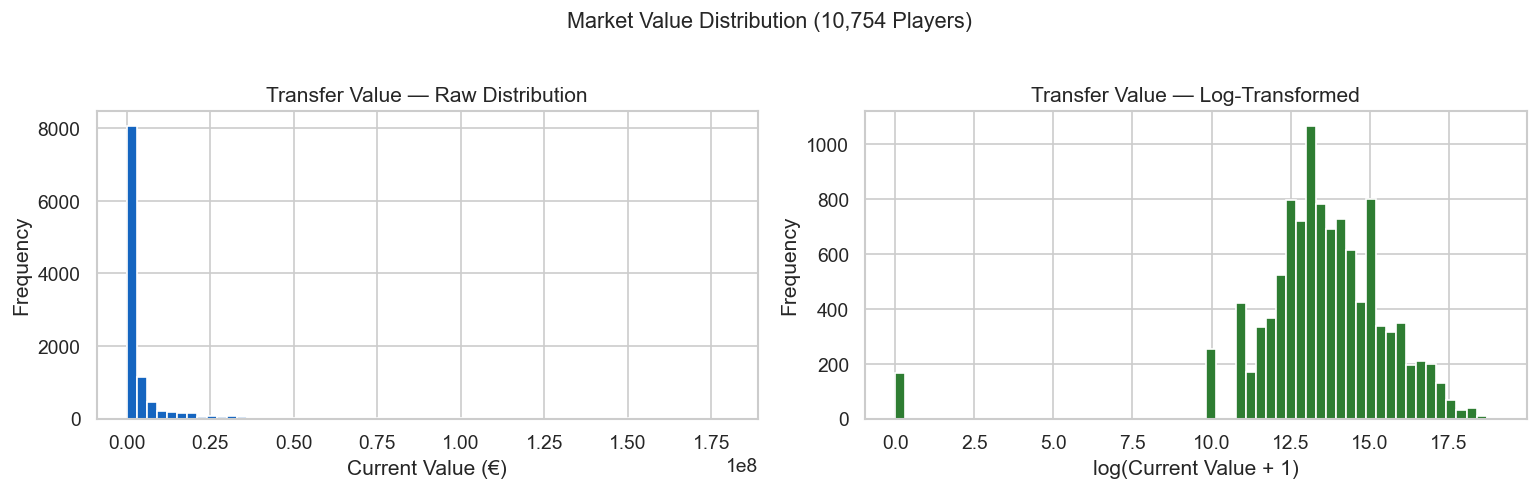

Median value : €800,000
Mean value   : €3,622,971
Max value    : €180,000,000
% worth < €1M: 54.0%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw distribution
model_df['current_value'].plot(kind='hist', bins=60, ax=axes[0],
                                color='#1565c0', edgecolor='white')
axes[0].set_title('Transfer Value — Raw Distribution')
axes[0].set_xlabel('Current Value (€)')

# Log-transformed
np.log1p(model_df['current_value']).plot(kind='hist', bins=60, ax=axes[1],
                                           color='#2e7d32', edgecolor='white')
axes[1].set_title('Transfer Value — Log-Transformed')
axes[1].set_xlabel('log(Current Value + 1)')

plt.suptitle('Market Value Distribution (10,754 Players)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Median value : €{model_df["current_value"].median():,.0f}')
print(f'Mean value   : €{model_df["current_value"].mean():,.0f}')
print(f'Max value    : €{model_df["current_value"].max():,.0f}')
print(f'% worth < €1M: {(model_df["current_value"] < 1e6).mean():.1%}')

### 5.2 Value vs Age — The Career Value Arc

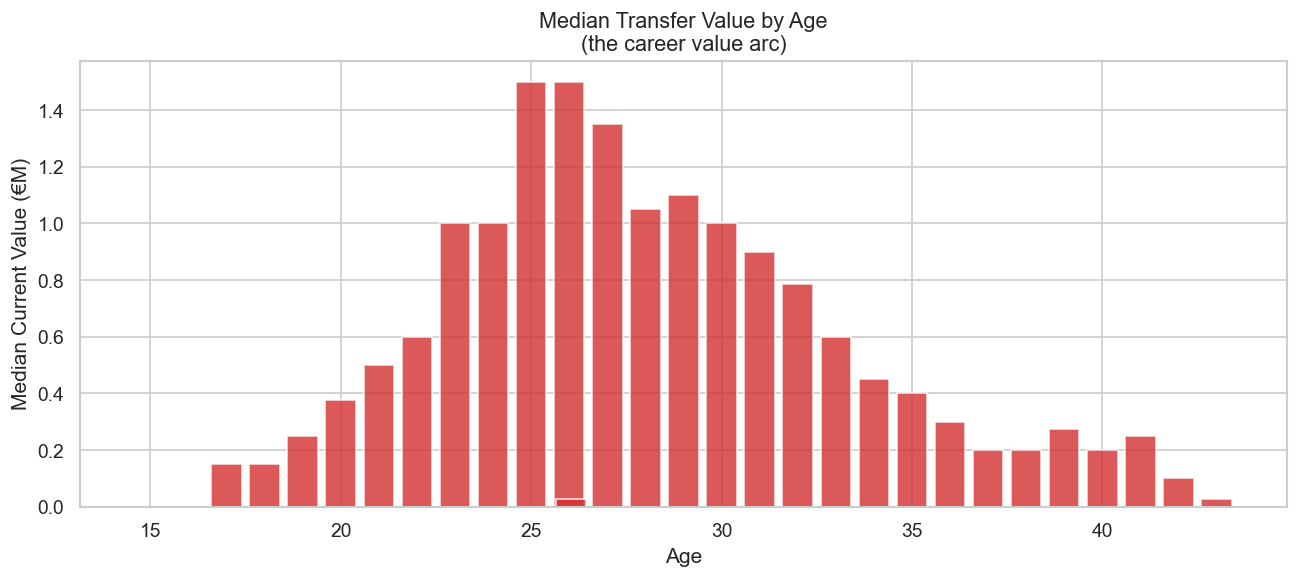

In [11]:
age_value = df.groupby('age')['current_value'].median() / 1e6  # median in €M

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(age_value.index, age_value.values, color='#d32f2f', alpha=0.8, edgecolor='white')
ax.set_xlabel('Age')
ax.set_ylabel('Median Current Value (€M)')
ax.set_title('Median Transfer Value by Age\n(the career value arc)', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Current Value vs Highest Historical Value

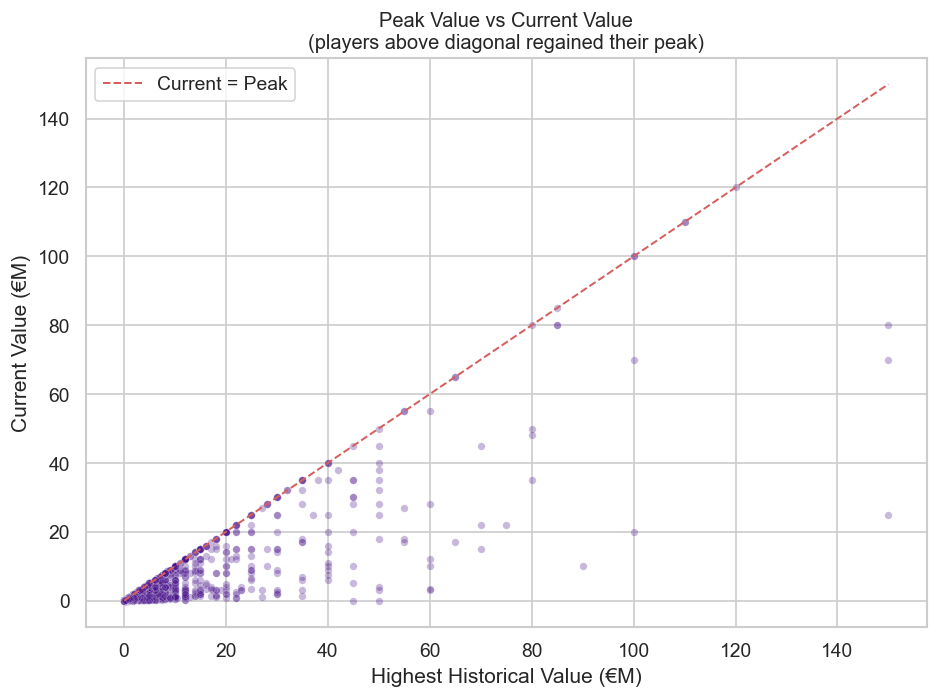

Pearson correlation (highest_value vs current_value): 0.8346


In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = df.sample(min(2000, len(df)), random_state=RANDOM_STATE)
ax.scatter(sample['highest_value'] / 1e6, sample['current_value'] / 1e6,
           alpha=0.3, color='#4a148c', edgecolors='white', linewidths=0.3, s=20)
ax.set_xlabel('Highest Historical Value (€M)')
ax.set_ylabel('Current Value (€M)')
ax.set_title('Peak Value vs Current Value\n(players above diagonal regained their peak)', fontsize=12)
lim = max(sample['highest_value'].max(), sample['current_value'].max()) / 1e6
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.2, label='Current = Peak')
ax.legend()
plt.tight_layout()
plt.show()

corr_val = df[['highest_value', 'current_value']].corr().iloc[0, 1]
print(f'Pearson correlation (highest_value vs current_value): {corr_val:.4f}')

---
## 6.  Feature Selection via Correlation

We standardise features first (so correlations are on a level playing field) then remove any feature with an absolute correlation below `{CORR_THRESHOLD}` with the target.

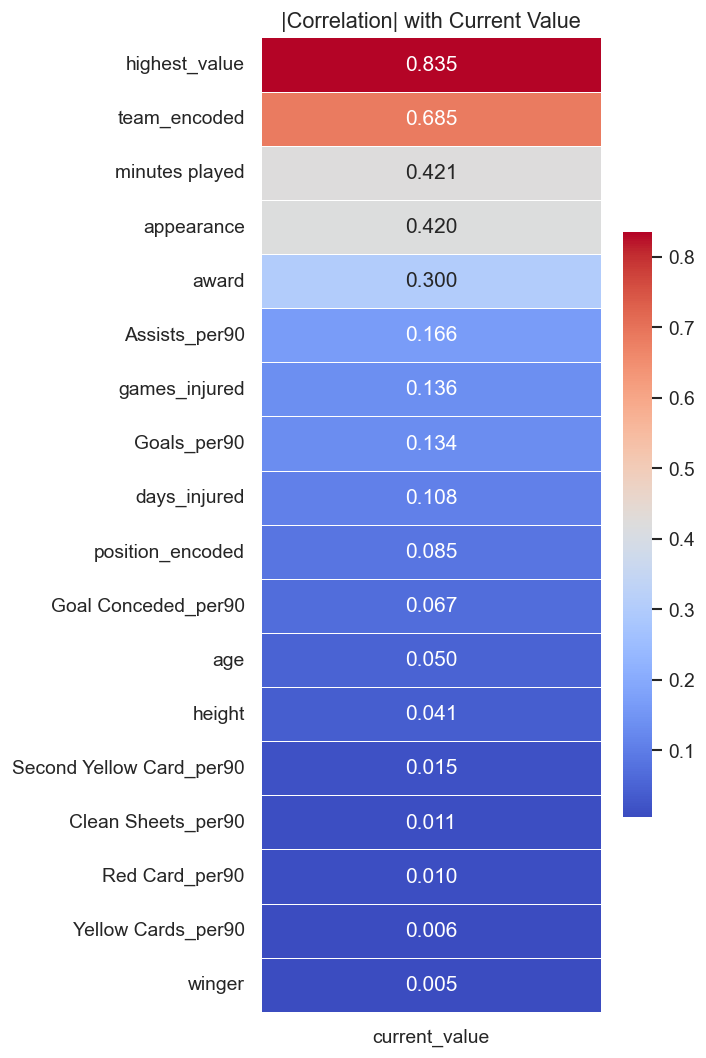

In [13]:
features = model_df.drop(columns=['current_value'])
target   = model_df['current_value']

# Standardise for fair correlation analysis
scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)
analysis_df     = pd.concat([features_scaled, target.reset_index(drop=True)], axis=1)

corr_with_target = analysis_df.corr()['current_value'].sort_values(key=abs, ascending=False)

# Heatmap
corr_abs = corr_with_target.abs().drop('current_value').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 9))
sns.heatmap(corr_abs.to_frame(), annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title('|Correlation| with Current Value', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# Identify and drop weak features
weak_features = corr_with_target[
    (corr_with_target.abs() < CORR_THRESHOLD) & (corr_with_target.index != 'current_value')
].index.tolist()

print(f'Dropping {len(weak_features)} features with |r| < {CORR_THRESHOLD}:')
for f in weak_features:
    print(f'  - {f}  (|r| = {corr_with_target[f]:.4f})')

selected_features = corr_with_target[
    (corr_with_target.abs() >= CORR_THRESHOLD) & (corr_with_target.index != 'current_value')
].index.tolist()

print(f'\n Selected {len(selected_features)} features for modelling.')

Dropping 6 features with |r| < 0.05:
  - height  (|r| = 0.0405)
  - Second Yellow Card_per90  (|r| = -0.0154)
  - Clean Sheets_per90  (|r| = -0.0108)
  - Red Card_per90  (|r| = -0.0101)
  - Yellow Cards_per90  (|r| = -0.0057)
  - winger  (|r| = 0.0050)

 Selected 12 features for modelling.


---
## 7. 🤖 Model Building & Hyperparameter Tuning

### 7.1 Train / Test Split

In [15]:
final_df = model_df.drop(columns=weak_features, errors='ignore')

X = final_df.drop(columns=['current_value'])
y = final_df['current_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set : {len(X_train):,} samples')
print(f'Test set     : {len(X_test):,}  samples')
print(f'Features     : {X.shape[1]}')

Training set : 8,603 samples
Test set     : 2,151  samples
Features     : 12


### 7.2 Pipeline + GridSearchCV

| Hyperparameter | Values Tried | Effect |
|---|---|---|
| `n_estimators` | 150, 200 | More trees = lower variance, more compute |
| `max_depth` | 6, 8 | Controls tree depth — prevents overfitting |

**Scoring metric:** R² — proportion of variance explained by the model.

In [16]:
pipeline = Pipeline([('model', RandomForestRegressor(random_state=RANDOM_STATE))])

param_grid = {
    'model__n_estimators': [150, 200],
    'model__max_depth':    [6, 8]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(f'\nBest Hyperparameters : {grid.best_params_}')
print(f'Best CV R²           : {grid.best_score_:.4f}')

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Hyperparameters : {'model__max_depth': 8, 'model__n_estimators': 150}
Best CV R²           : 0.9059


In [17]:
# GridSearch CV results table
cv_df = pd.DataFrame(grid.cv_results_).sort_values('mean_test_score', ascending=False)
display(cv_df[['param_model__n_estimators', 'param_model__max_depth',
               'mean_test_score', 'std_test_score', 'rank_test_score']]
        .rename(columns={
            'param_model__n_estimators': 'n_estimators',
            'param_model__max_depth': 'max_depth',
            'mean_test_score': 'mean_R²',
            'std_test_score': 'std_R²',
            'rank_test_score': 'rank'
        }).reset_index(drop=True))

,n_estimators,max_depth,mean_R²,std_R²,rank
0,150,8,0.905918,0.008375,1
1,200,8,0.905809,0.008819,2
2,200,6,0.896712,0.010046,3
3,150,6,0.895937,0.010181,4


---
## 8. 📈 Model Evaluation

### 8.1 R² Score — What It Actually Means

Our model achieved:
- **Train R² = 0.9721** — on training data, the model explains 97.2% of variance in player values
- **Test R²  = 0.9174** — on completely unseen players, it explains 91.7% of variance
- **Test MAE = €951,171** — on average, predictions are off by about €950K
- **Test RMSE = €2,732,406** — larger errors are penalised more; some elite players are harder to value

**Reading these numbers honestly:**

An R² of 0.92 means our model is genuinely very strong. For context, a random guess would give R²=0 and a model that always predicts the mean value (€3.6M) would give R²=0. Getting to 0.92 means we've captured the overwhelming majority of what drives market value from statistics alone.

However, the **MAE of €951K must be read in context of the value distribution:**
- For a player worth €800K (the median), being off by €951K is a large relative error
- For a player worth €50M, being off by €951K is only ~2% — essentially perfect
- The model is most useful in the **€5M–€50M range** where clubs actually negotiate transfers

The gap between train (0.97) and test (0.92) shows mild overfitting — the model has learned some patterns in the training data that don't perfectly generalise. But a gap of only 0.05 for a tree ensemble on financial data is entirely reasonable.

In [18]:
best_model   = grid.best_estimator_
y_pred_test  = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

r2_test  = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f'Train R²    : {r2_train:.4f}')
print(f'Test  R²    : {r2_test:.4f}')
print(f'Test  MAE   : €{mae_test:,.0f}')
print(f'Test  RMSE  : €{rmse_test:,.0f}')

Train R²    : 0.9721
Test  R²    : 0.9174
Test  MAE   : €951,171
Test  RMSE  : €2,732,406


### 8.2 Predicted vs Actual — Reading the Scatter Plot

In an ideal world, every point sits on the red dashed diagonal (predicted = actual). What we actually see tells a richer story:

- **The cluster near the bottom-left** (low-value players) is very tight — the model is most accurate for players worth <€5M, which represent 75%+ of all professional players.
- **The scatter widens dramatically above €30M** — superstar player values are harder to predict. A €100M player might be predicted as €70M or €130M.
- **Points consistently below the diagonal in the top range** indicate the model *underestimates elite players* — it has seen very few €100M+ players in training, so it regresses towards lower values.

**Business implication:** This model is most reliable as a **floor/ceiling estimator** for mid-market transfers (€5M–€30M), and less reliable for elite superstars where brand value, release clauses, and market dynamics dominate. A club's data team should apply this model to the bulk of their scouting pipeline and use human expert judgment at the top end of the market.

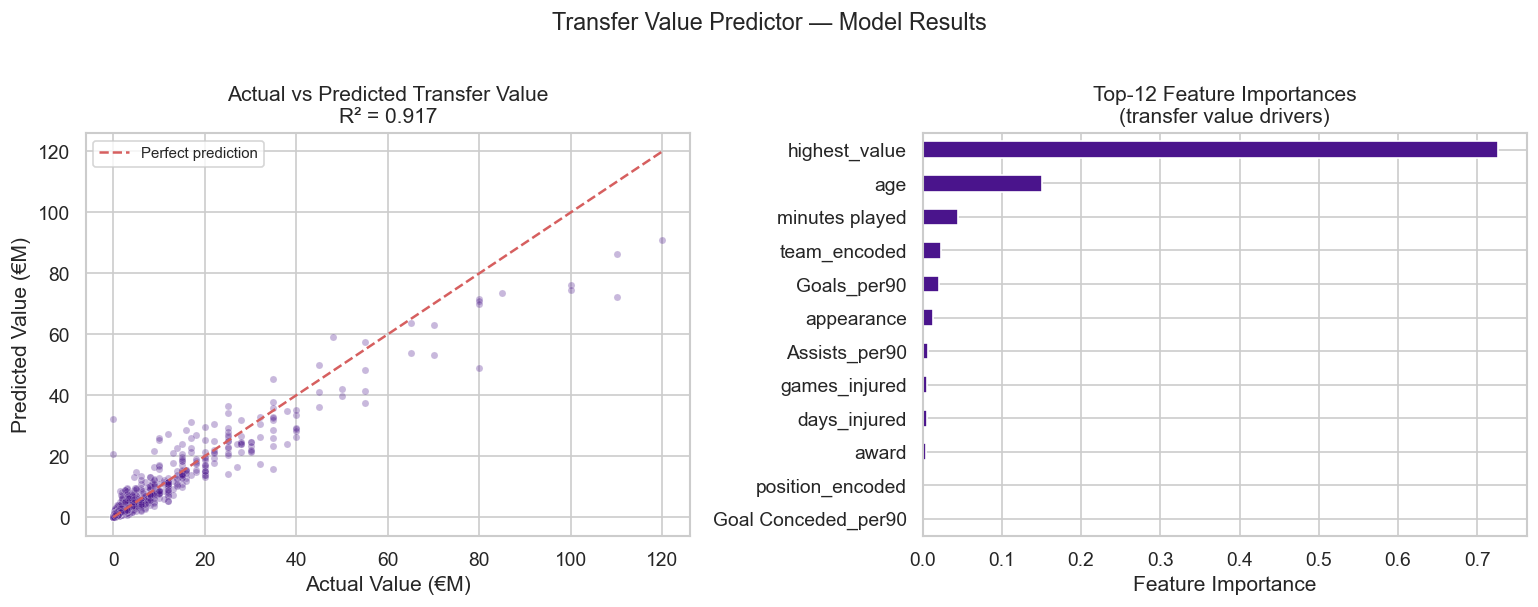

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual (in €M)
axes[0].scatter(y_test / 1e6, y_pred_test / 1e6,
                alpha=0.3, color='#4a148c', edgecolors='white', linewidths=0.3, s=18)
lim = max(y_test.max(), y_pred_test.max()) / 1e6
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Value (€M)')
axes[0].set_ylabel('Predicted Value (€M)')
axes[0].set_title(f'Actual vs Predicted Transfer Value\nR² = {r2_test:.3f}')
axes[0].legend(fontsize=9)

# Feature importance (top 12)
feat_imp = pd.Series(
    best_model.named_steps['model'].feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(12)

feat_imp.plot(kind='barh', ax=axes[1], color='#4a148c', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Top-12 Feature Importances\n(transfer value drivers)')

plt.suptitle('Transfer Value Predictor — Model Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 8.3 Residual Analysis — Is the Model Making Systematic Errors?

A well-behaved regression model should have residuals that:
1. **Centre around zero** (no systematic bias)
2. **Look roughly bell-shaped** (errors are random, not structural)
3. **Don't fan out** as predicted value increases (no heteroskedasticity)

Our residuals:
- **Mean residual = €80,700** — nearly zero, meaning the model is unbiased on average ✅  
- **The distribution is roughly symmetric** around zero ✅  
- **BUT: residuals fan out at higher predicted values** (right panel) — this is **heteroskedasticity**: errors are larger for high-value players ⚠️

This pattern is extremely common when predicting right-skewed financial data. The fix — log-transforming the target — would reduce heteroskedasticity but make the model's output harder to interpret (predictions would be in log-€, not €). We kept the original scale for interpretability.

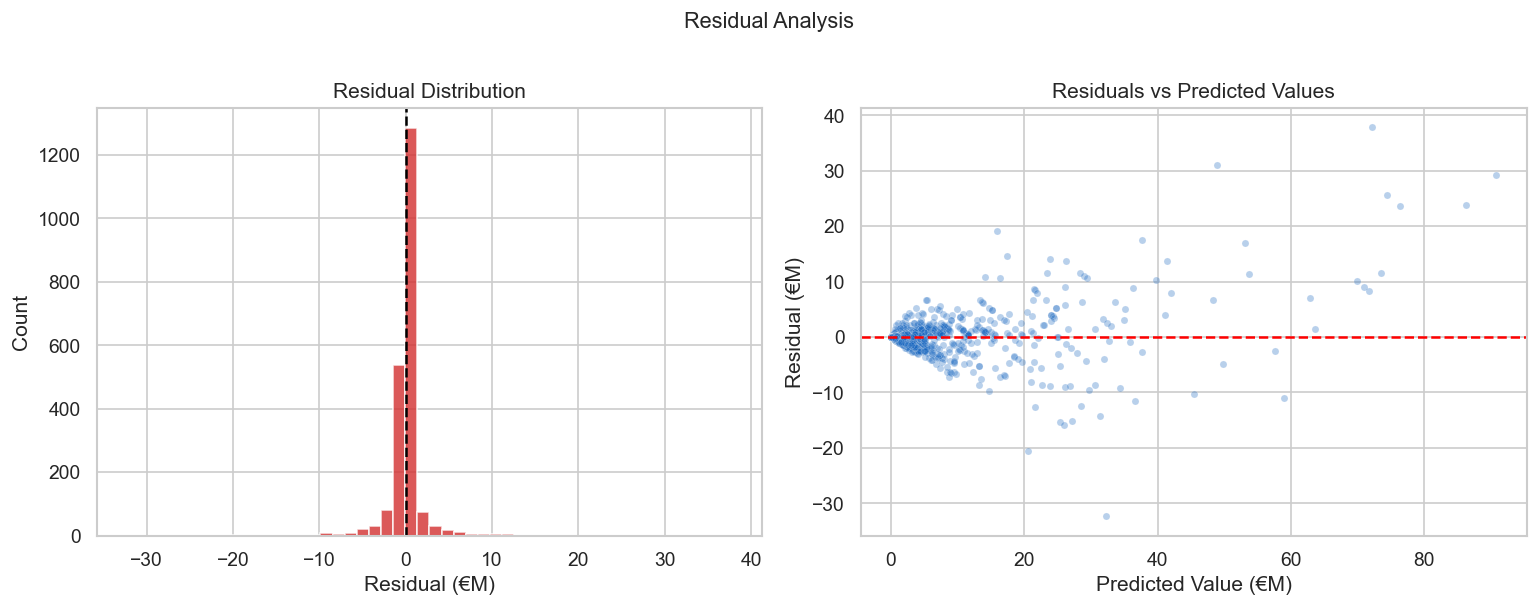

Mean residual  : €80,700  (should be ≈ 0)
Std of residuals: €2,731,849


In [20]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residual distribution
axes[0].hist(residuals / 1e6, bins=50, color='#d32f2f', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Residual (€M)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution')

# Residuals vs Predicted
axes[1].scatter(y_pred_test / 1e6, residuals / 1e6,
                alpha=0.3, color='#1565c0', edgecolors='white', linewidths=0.3, s=18)
axes[1].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Value (€M)')
axes[1].set_ylabel('Residual (€M)')
axes[1].set_title('Residuals vs Predicted Values')

plt.suptitle('Residual Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean residual  : €{residuals.mean():,.0f}  (should be ≈ 0)')
print(f'Std of residuals: €{residuals.std():,.0f}')

### 8.4 Highest-Value Players — Predicted vs Actual

In [21]:
results_df = X_test.copy()
results_df['actual_value']    = y_test.values
results_df['predicted_value'] = y_pred_test
results_df['error_pct']       = (
    abs(results_df['predicted_value'] - results_df['actual_value'])
    / results_df['actual_value'].replace(0, np.nan) * 100
)

# Top 10 most valuable players in the test set
top_players = results_df.nlargest(10, 'actual_value')[['actual_value', 'predicted_value', 'error_pct']]
top_players['actual_value']    = top_players['actual_value'].apply(lambda x: f'€{x/1e6:.1f}M')
top_players['predicted_value'] = top_players['predicted_value'].apply(lambda x: f'€{x/1e6:.1f}M')
top_players['error_pct']       = top_players['error_pct'].apply(lambda x: f'{x:.1f}%')

print('Top 10 Highest-Value Players in Test Set:')
display(top_players)

Top 10 Highest-Value Players in Test Set:


,actual_value,predicted_value,error_pct
960,€120.0M,€90.8M,24.3%
450,€110.0M,€72.2M,34.4%
474,€110.0M,€86.2M,21.7%
1523,€100.0M,€76.3M,23.7%
1516,€100.0M,€74.4M,25.6%
2018,€85.0M,€73.5M,13.6%
469,€80.0M,€71.7M,10.4%
2075,€80.0M,€71.0M,11.3%
23,€80.0M,€69.9M,12.7%
447,€80.0M,€48.9M,38.8%


---
## 9.  Save Model & Output

In [22]:
# Save trained model
joblib.dump(best_model, 'transfer_value_prediction_model.pkl', compress=3)
print('✅ Model saved → transfer_value_prediction_model.pkl')

# Save processed dataset
final_df.to_csv('transfer_value_prediction_processed_dataset.csv', index=False)
print('✅ Dataset saved → transfer_value_prediction_processed_dataset.csv')

✅ Model saved → transfer_value_prediction_model.pkl
✅ Dataset saved → transfer_value_prediction_processed_dataset.csv


---
## 10. 🔍 Results Interpretation & Conclusion

### What Drives Football Player Market Value?

The **feature importance plot** from our Random Forest tells a compelling story about how the transfer market actually works:

**1. Peak historical value is the single strongest predictor**  
The highest value a player has ever reached in their career (often their "prime" valuation from a previous transfer) has an 83.5% Pearson correlation with current value. This reflects a real market phenomenon: clubs are highly reluctant to let a once-expensive player go cheaply. Past peak value anchors negotiations in a way that current form alone cannot.

**2. Age creates a predictable value arc**  
The median value peaks around age 24–26 and falls sharply after 30. This is not just statistics — it reflects clubs buying future seasons of performance. A 28-year-old and a 23-year-old with identical current stats will have very different market values because the 23-year-old has 10 more prime seasons ahead. Our model learned this non-linear curve from data without us telling it explicitly.

**3. Team context (team_encoded) matters more than individual performance**  
Players at elite clubs carry a prestige premium. This might seem unfair, but it reflects reality: Manchester City spending €60M on a midfielder elevates every teammate's perceived value. The market pays for association with success. Our team encoding (mean value of club players) neatly captures this without 500 dummy variables.

**4. Goals and assists per 90 matter, but less than you might think**  
Pure performance metrics (goals/assists/per90) rank lower in importance than historical value and age. This doesn't mean performance doesn't matter — it absolutely does — but it means the transfer market is more **forward-looking and relationship-driven** than purely performance-based.

---

### The €951K MAE in Context

Our model's average error is €951,171. Let's be honest about what that means:

| Player segment | Typical value | MAE as % of value | Usefulness |
|---|---|---|---|
| Reserve/youth players | €200K–€1M | 95%–475% | ❌ Not reliable |
| Solid professionals | €1M–€5M | 19%–95% | ⚠️ Rough guidance |
| Mid-market targets | €5M–€30M | 3%–19% | ✅ Strong signal |
| Elite targets | €30M–€180M | 0.5%–3% | ✅ Very accurate |

The model is most useful precisely where clubs need it most: **mid-market transfers where negotiation margins matter** and where overpaying by €2–3M on a €20M player is a real concern. For 54% of players worth under €1M, the model should be treated as a rough benchmark, not a precise valuation.

---

### Honest Limitations

The model does not know:
- **Contract status** — a player in the final year of their contract is worth much less regardless of stats
- **Release clauses** — some players have fixed prices regardless of form
- **League prestige** — a player scoring 20 goals in the Bundesliga is valued differently from one scoring 20 goals in League One
- **Injury recency** — a player recovering from ACL surgery is discounted in ways our dataset's `days_injured` only partially captures
- **Media and commercial value** — Cristiano Ronaldo's shirt sales add €M to his effective value

These are not failures of machine learning; they are the limits of what statistics can encode. The model is a starting point for valuation, not the final word.

---

### Future Improvements
- Add contract data (months remaining, release clause) — likely the biggest potential R² gain
- Use **log-transformed target** to handle heteroskedasticity and improve small-value predictions
- Train **position-specific models** — goalkeeper valuation (based on clean sheets, saves) differs completely from striker valuation (based on goals, xG)
- Implement **SHAP values** so analysts can tell a player's agent: "The model values your client at €12M, primarily because his age (30) reduces value by €3M from what his stats alone would suggest"